# Airbnb NYC 2019 — Análisis Exploratorio de Datos

En este proyecto voy a hacer una análisis exploratorio de datos para buscar las diferencias y entender los siguientes apartados:
- Cómo se distribuyen los precios
- Qué diferencias hay entre barrios
- Cómo influye el tipo de Airbnb en el precio
- Qué variables están relacionadas entre sí

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 1. Carga del dataset

In [20]:
df = pd.read_csv('/content/sample_data/AB_NYC_2019.csv')

print(f'Filas: {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
df.head()

Filas: 48,895
Columnas: 16


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [21]:
# Ver los tipos de datos de cada columna
df.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


In [22]:
# Estadísticas básicas de las columnas numéricas
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


## 2. Limpieza de datos

Antes que nada hay que ver si hay valores nulos o datos raros.

In [23]:
# Valores nulos por columna
print('Valores nulos:')
print(df.isnull().sum())

Valores nulos:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


**¿Qué hacer con los valores nulos?**

- `last_review` y `reviews_per_month` tienen 10.052 nulos — no son errores. Simplemente no tienen ninguna reseña todavía. Les cambio el valor a 0.
- `name` y `host_name` tienen muy pocos nulos (16 y 21), Los dejo.

También hay varios casos que tiene precios, no tiene sentido, los elimino también.

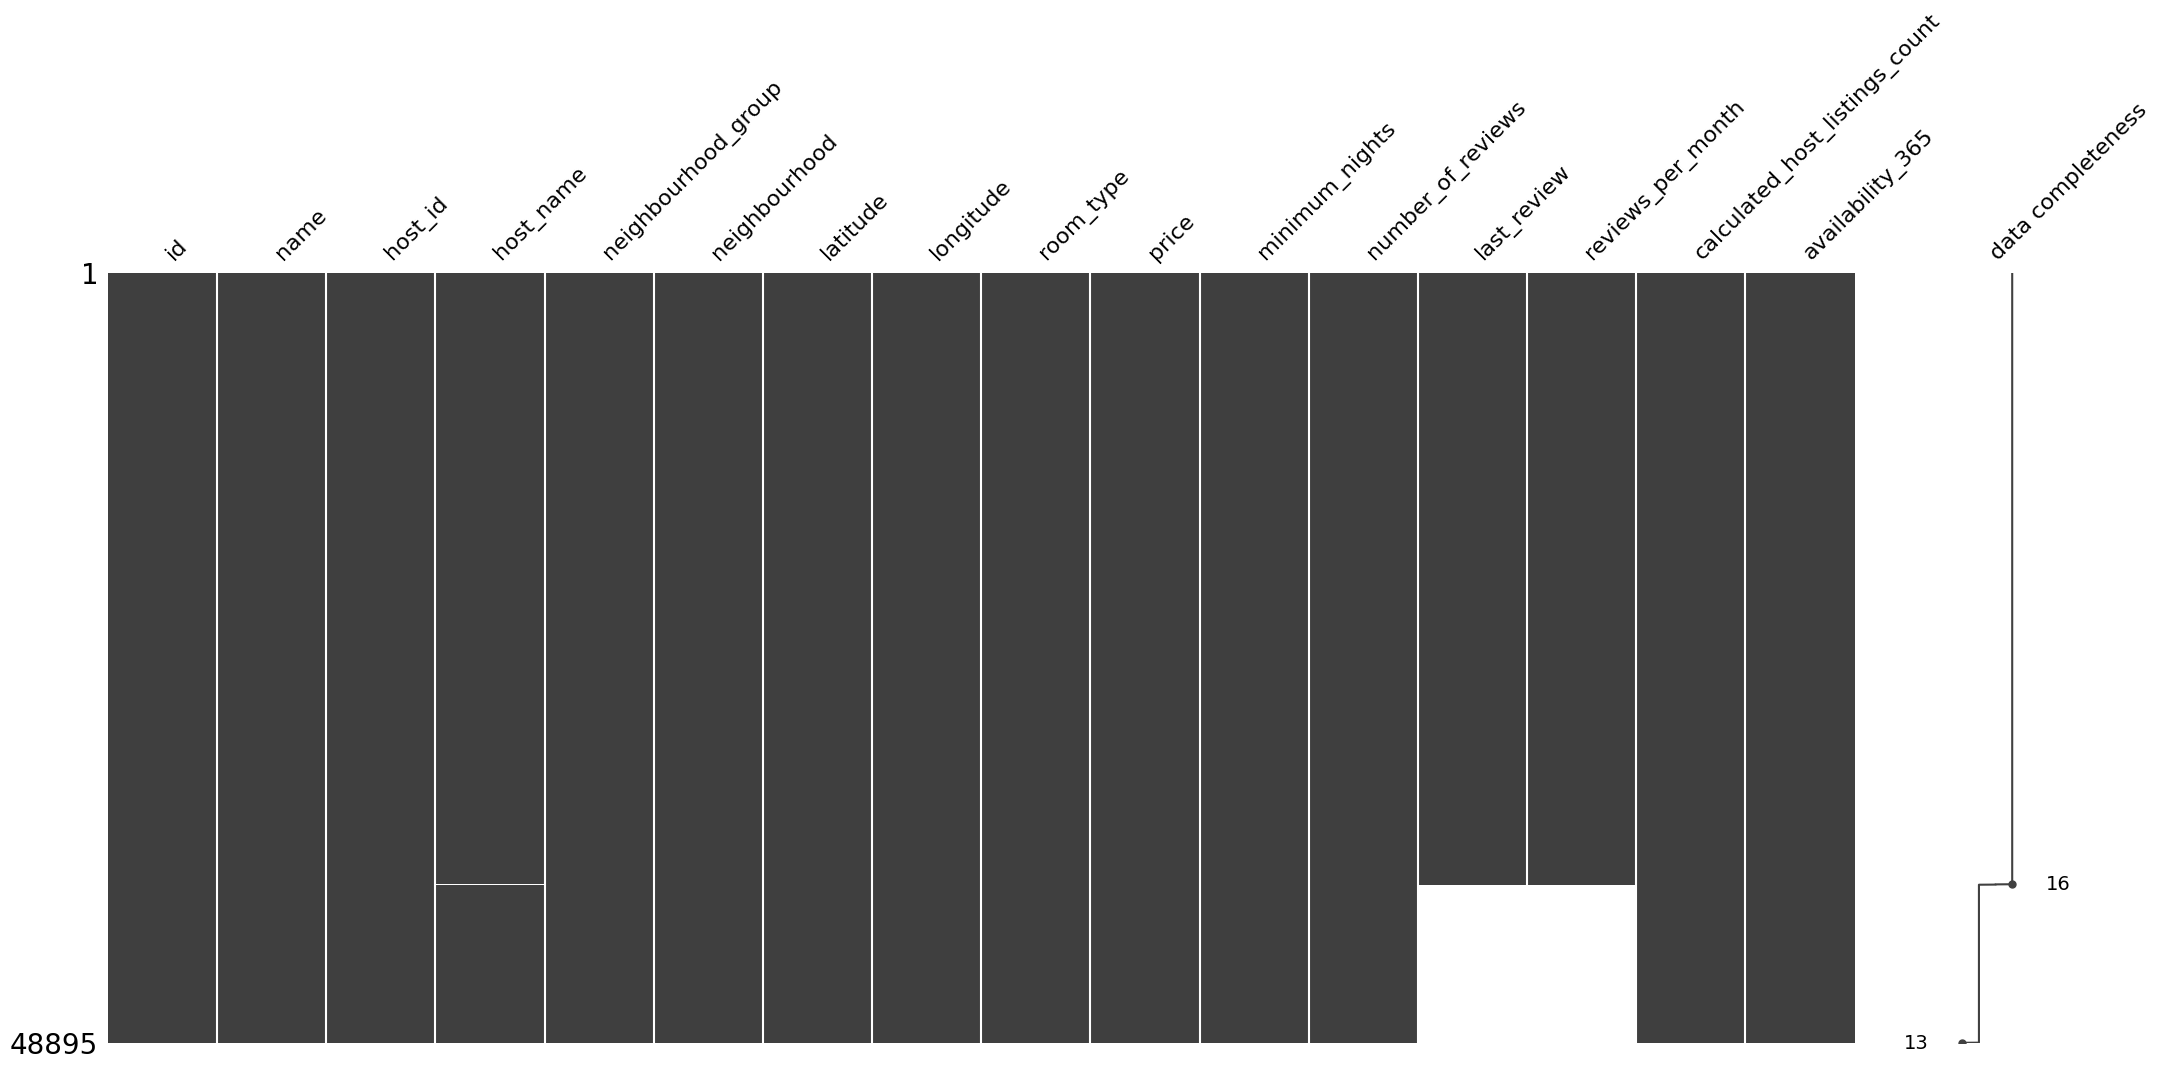

In [24]:
# Tabla de valores nulos
import missingno as msno
msno.matrix(df, labels=True, sort="descending");

In [25]:
# Rellenar nulos de reviews con 0
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Eliminar airbnb con precio 0
df = df[df['price'] > 0]

print(f'Filas tras limpiar: {len(df):,}')

Filas tras limpiar: 48,884


## 3. Distribución de precios

La primera pregunta es: ¿Cómo se distribuyen los precios? ¿Hay muchos Airbnb caros o son la mayoría baratos?

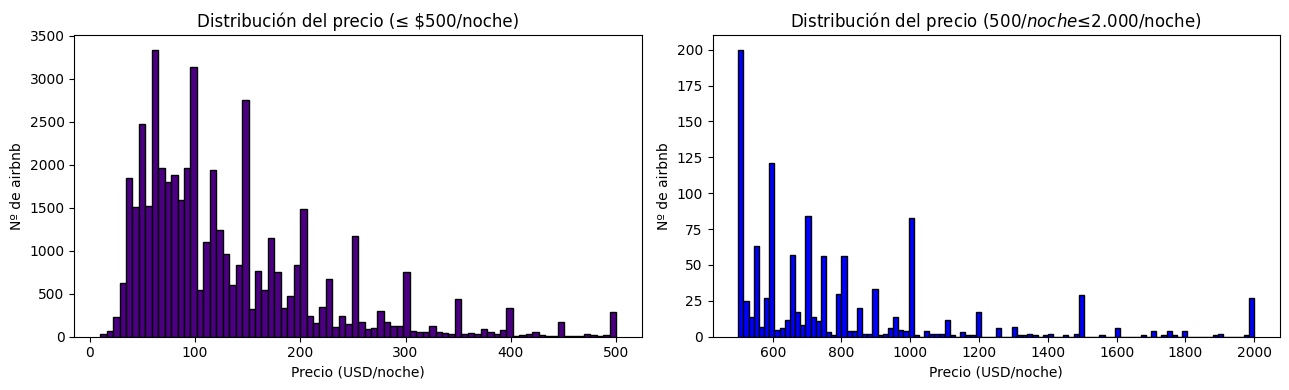

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma quitando outliers (precio hasta 500)
axes[0].hist(df[df['price'] <= 500]['price'],
             bins=80,
             color='indigo',
             edgecolor='black')
axes[0].set_title('Distribución del precio (≤ $500/noche)')
axes[0].set_xlabel('Precio (USD/noche)')
axes[0].set_ylabel('Nº de airbnb')

# Histograma de segmentado de precios (500 hasta 2000)
df_rango = df[(df['price'] >= 500) & (df['price'] <= 2000)]
axes[1].hist(df_rango['price'],
             bins=100,
             color='blue',
             edgecolor='black')
axes[1].set_title('Distribución del precio ($500/noche ≤ $2.000/noche)')
axes[1].set_xlabel('Precio (USD/noche)')
axes[1].set_ylabel('Nº de airbnb')

plt.tight_layout()
plt.show()


**Análisis:**

En el primer gráfico, limitando el precio a 500 dollares, podemos apreciar mejor la diferncia de precio medio por noche en un Airbnb en Nueva York,siendo claro que la media de Airbnb en Nueva york va de dlos 50 a los 200 dollares por noche.

En el segundo histograma la distribución esta muy concentrada en lado izquierdo y muy sesgada en el lado derecho, esto nos da a entender que la media de preciso en Nueva York es de entre 50 a 200 dollares la noche, el resto, problabemente sean mansiones o apartementso de lujo en Manhattan.


## 4. Diferencias de precio entre barrios (neighbourhood_group)

Nueva York tiene 5 barrios o boroughs: Manhattan, Brooklyn, Queens, Bronx y Staten Island. ¿Cuál es más caro? ¿Hay mucha diferencia?

Dentro de estos de estos 5 barrios hay barrios más pequeños, los llamaremos neighbourhoods para diferenciarlos.

In [27]:
# Cuántos Airbnb hay en cada barrio
print('Número de Airbnb por barrio:')
print(df['neighbourhood_group'].value_counts())
print(f'\nTotal: {len(df):,}')

Número de Airbnb por barrio:
neighbourhood_group
Manhattan        21660
Brooklyn         20095
Queens            5666
Bronx             1090
Staten Island      373
Name: count, dtype: int64

Total: 48,884


In [28]:
# Precio mediana por barrio
mediana_barrios = df.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False)
print('Precio mediana por barrio (USD/noche):')
print(mediana_barrios)

Precio mediana por barrio (USD/noche):
neighbourhood_group
Manhattan        150.0
Brooklyn          90.0
Queens            75.0
Staten Island     75.0
Bronx             65.0
Name: price, dtype: float64


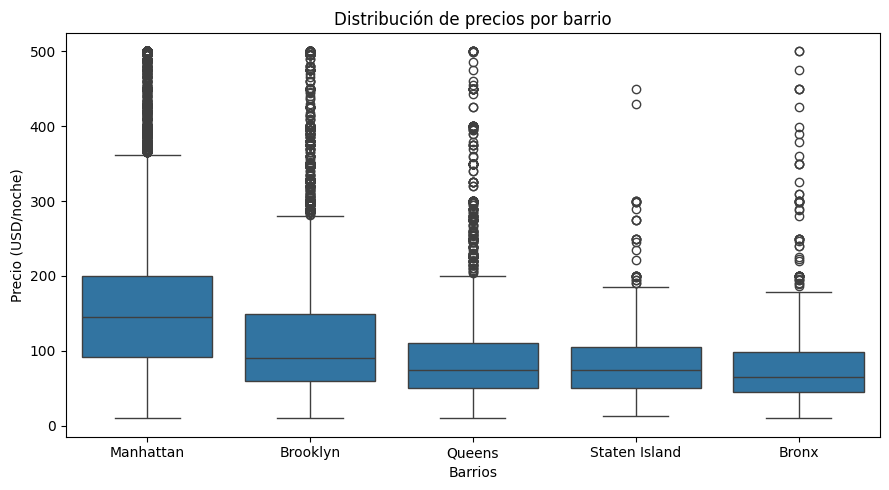

In [29]:
# Boxplot de precios por barrios (quitamos outliers para que se vea más claro)
df_plot = df[df['price'] <= 500]
order = df_plot.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False).index

plt.figure(figsize=(9, 5))
sns.boxplot(data=df_plot,
            x='neighbourhood_group',
            y='price',
            order=order)
plt.title('Distribución de precios por barrio')
plt.xlabel('Barrios')
plt.ylabel('Precio (USD/noche)')
plt.tight_layout()
plt.show()

**Análisis:**

- **Manhattan** es el más caro con diferencia el precio mediano de 150 dollares por noche, y mucha variedad (dentro de Manhattan hay barrios que superan los 300 dollares).

- **Brooklyn** está justo detrás, siendo también la zona con más Airbnb en alquiler, unos 20.000. Es el barrio más popular y activo.

- **Staten Island** sorprende: pese a ser poco popular y tener muy pocos Airbnb (menos de 400 dollares), la mediana de sus precios es superior a Queens y Bronx.

- **Bronx** es consistentemente el más barato, con menos variación en precios.

El boxplot muestra que **en todos los barrios hay outliers hacia arriba** — siempre hay algún Airbnb carísimo, pero la mayoría se agrupa en el rango bajo.

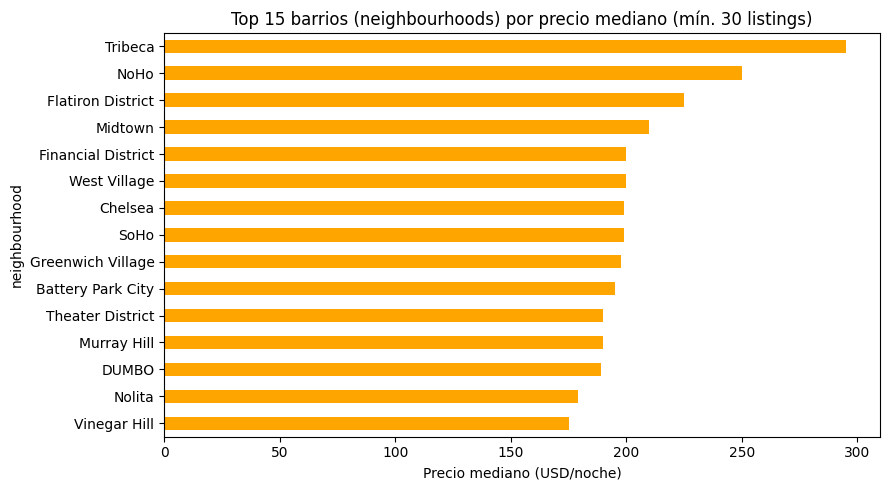

In [30]:
# Top 15 barrios (neighbourhoods) más caros — mínimo 30 Airbnb para que sea relevante
top_barrios = (
    df.groupby('neighbourhood')
    .filter(lambda x: len(x) >= 30)
    .groupby('neighbourhood')['price']
    .median()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(9, 5))
top_barrios.sort_values().plot(kind='barh', color='orange', edgecolor='none')
plt.title('Top 15 barrios (neighbourhoods) por precio mediano (mín. 30 listings)')
plt.xlabel('Precio mediano (USD/noche)')
plt.tight_layout()
plt.show()

## 5. Tipo de habitación

El dataset tiene tres tipos de Airbnb: `Entire home/apt`, `Private room` y `Shared room`. ¿Cuántos hay de cada uno? ¿cómo afecta al precio?

In [31]:
print('Distribución por tipo de Airbnb:')
print(df['room_type'].value_counts())
print()
print('Precio mediano por tipo (USD/noche):')
print(df.groupby('room_type')['price'].median().sort_values(ascending=False))

Distribución por tipo de Airbnb:
room_type
Entire home/apt    25407
Private room       22319
Shared room         1158
Name: count, dtype: int64

Precio mediano por tipo (USD/noche):
room_type
Entire home/apt    160.0
Private room        70.0
Shared room         45.0
Name: price, dtype: float64


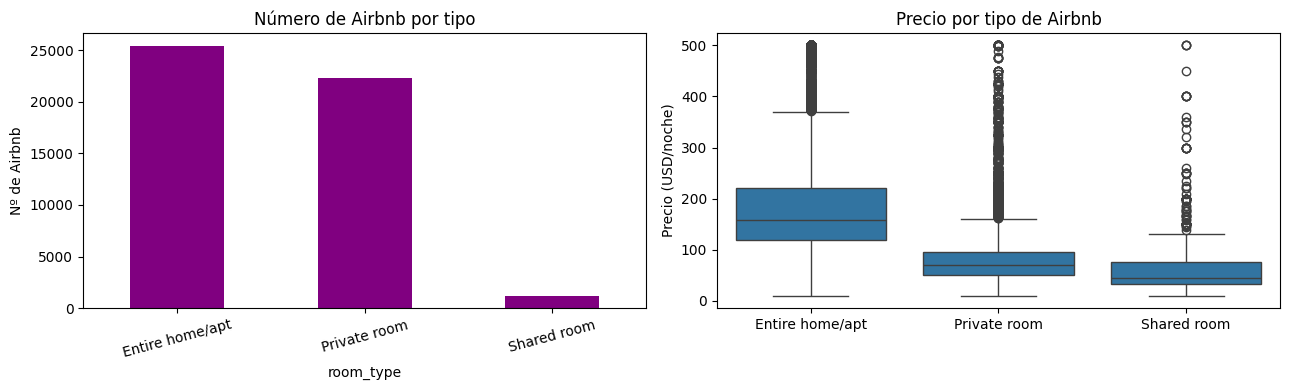

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Conteo
df['room_type'].value_counts().plot(kind='bar',
                                    ax=axes[0],
                                    color='purple',
                                    edgecolor='none',
                                    rot=15)
axes[0].set_title('Número de Airbnb por tipo')
axes[0].set_ylabel('Nº de Airbnb')

# Boxplot de precios
df_plot = df[df['price'] <= 500]
order = df_plot.groupby('room_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_plot, x='room_type', y='price', order=order, ax=axes[1])
axes[1].set_title('Precio por tipo de Airbnb')
axes[1].set_xlabel('')
axes[1].set_ylabel('Precio (USD/noche)')

plt.tight_layout()
plt.show()

**Análisis:**

- `Entire home/apt` y `Private room` se reparten casi todo el mercado con 52% y 46% respectivamente. `Shared room` es casi insignificante con un 2.4%.

- El precio de un piso entero prácticamente **es el doble** que el de una habitación privada con $160 `Entire home/apt` vs. ~$70 `Private room`de mediana.

- Los `Shared room` son los más baratos 45 dollares por noche, pero con mucha variación, hay algunos bastante caros.

El tipo de habitación es seguramente **la variable más importante** para predecir el precio, junto con la **ubicación**.

## 6. Precio por barrio Y tipo de habitación juntos

¿Qué pasa si combinamos las dos variables más importantes?

In [33]:
# Tabla: precio mediano por barrio y tipo de habitación
pivot = df.groupby(['neighbourhood_group', 'room_type'])['price'].median().unstack()
print('Mediana de precios (USD/noche):')
print(pivot.round(0))

Mediana de precios (USD/noche):
room_type            Entire home/apt  Private room  Shared room
neighbourhood_group                                            
Bronx                          100.0          54.0         40.0
Brooklyn                       145.0          65.0         36.0
Manhattan                      191.0          90.0         69.0
Queens                         120.0          60.0         37.0
Staten Island                  100.0          50.0         30.0


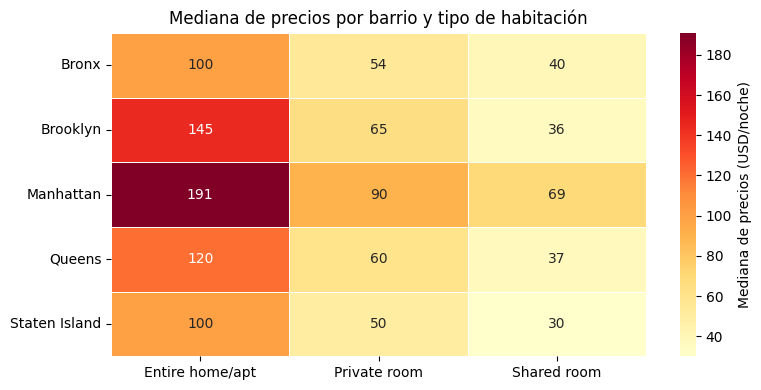

In [34]:
plt.figure(figsize=(8, 4))
sns.heatmap(pivot,
            annot=True,
            fmt='.0f',
            cmap='YlOrRd',
            linewidths=0.5,
            cbar_kws={'label': 'Mediana de precios (USD/noche)'})
plt.title('Mediana de precios por barrio y tipo de habitación')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Análisis:**

Este heatmap es un gráfico clave para este análisis. En un vistazo:

- **Manhattan + Entire home/apt** es la combinación más cara unos 190 dollares/noche. Casi el doble que el mismo tipo en Brooklyn.

- Una **habitación privada en Manhattan** (90 dollares) cuesta lo mismo que un **piso entero en el Bronx**. La ubicación puede compensar completamente el tipo.

- **Staten Island** tiene un comportamiento atípico para `Entire home/apt`: precio similar a Manhattan, aunque tiene muy pocos Airbnb, algo a tener en cuenta.

- **Queens** y **Bronx** comparten valores muy similares.


## 7. Otras variables relevantes

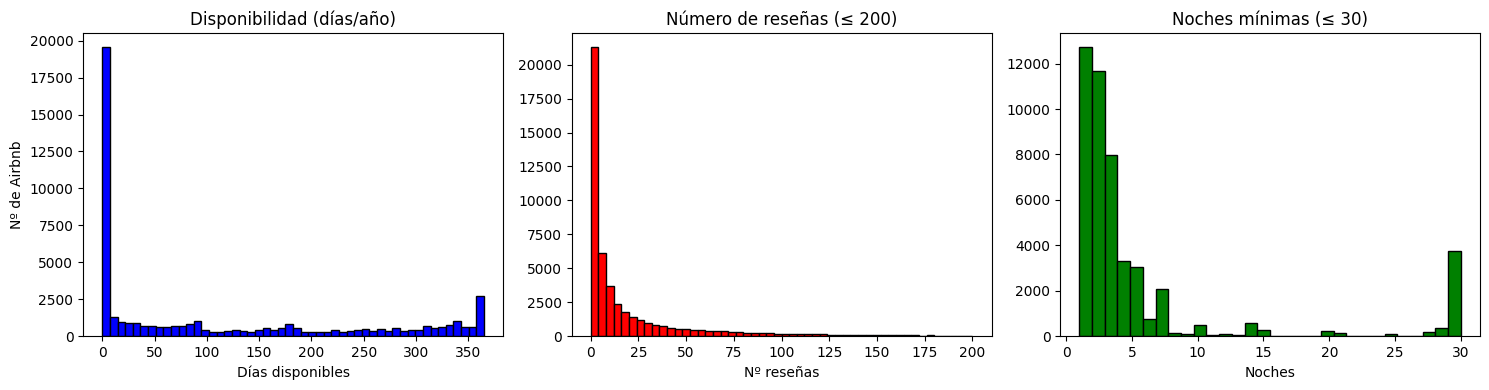

Airbnb con disponibilidad 0 días: 35.9%
Airbnb con mínimo 1 noche:        26.0%


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Disponibilidad
axes[0].hist(df['availability_365'],
             bins=50,
             edgecolor='black',
             color='blue')
axes[0].set_title('Disponibilidad (días/año)')
axes[0].set_xlabel('Días disponibles')
axes[0].set_ylabel('Nº de Airbnb')

# Reviews (filtrando para que se vea)
axes[1].hist(df[df['number_of_reviews'] <= 200]['number_of_reviews'],
             bins=50,
             edgecolor='black',
             color='red')
axes[1].set_title('Número de reseñas (≤ 200)')
axes[1].set_xlabel('Nº reseñas')

# Noches mínimas
axes[2].hist(df[df['minimum_nights'] <= 30]['minimum_nights'],
             bins=30,
             edgecolor='black',
             color='green')
axes[2].set_title('Noches mínimas (≤ 30)')
axes[2].set_xlabel('Noches')

plt.tight_layout()
plt.show()

pct_zero_avail = (df['availability_365'] == 0).mean() * 100
pct_one_night  = (df['minimum_nights'] == 1).mean() * 100
print(f'Airbnb con disponibilidad 0 días: {pct_zero_avail:.1f}%')
print(f'Airbnb con mínimo 1 noche:        {pct_one_night:.1f}%')

**Análisis:**

- **Disponibilidad**: distribución bimodal muy curiosa, hay muchos Airbnb con 0 días disponibles (probablemente ya alquilados o inactivos) y muchos con 365 días. Los del centro representan los que están parcialmente disponibles.
- **Reseñas**: la mayoría tiene muy pocas. Es una distribución muy sesgada — unos pocos listings acumulan cientos de reseñas.
- **Noches mínimas**: la mayoría exige solo 1 noche, aunque hay airbnb con mínimos absurdos (>365 noches), lo que sugiere que son arrendamientos a largo plazo publicados en Airbnb.

## 8. Correlaciones entre variables numéricas


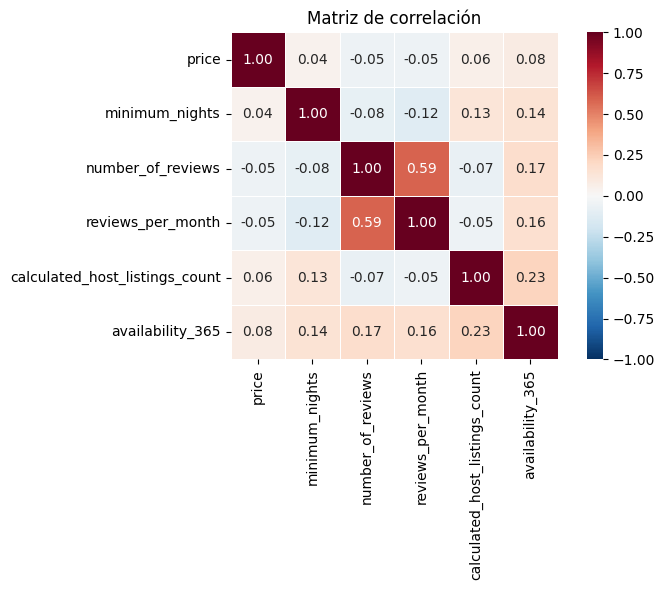

In [36]:
cols = ['price', 'minimum_nights', 'number_of_reviews',
        'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

corr = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

**Análisis:**

En general las correlaciones son bastante bajas, lo que tiene sentido, el precio depende más de variables categóricas (barrio, tipo) que de las numéricas.

Lo más destacable:
- `number_of_reviews` y `reviews_per_month` están muy relacionados, al final, es lo mismo pero medido distinto.
- `price` apenas correlaciona con nada de forma lineal. La relación con el barrio y tipo de Airbnb es mucho más explicativa.
- `calculated_host_listings_count` correlaciona levemente positivo con `availability_365`: los hosts con varios pisos tienden a tenerlos más disponibles.

## 9. Conclusiones

### Lo más importante de este dataset

**Los precios:**
- La distribución es muy asimétrica, la mediana DE 106 dollares es más representativa que la media 152 dollares.

- El rango "normal" para la mayoría de listings está entre 50 dollares y 175 dollares.

**Los barrios:**
- Manhattan lidera en precio, pero Brooklyn tiene más actividad, más Airbnb y más reseñas.
- La diferencia de precio entre barrios puede ser tan grande como la diferencia entre tipos de habitación.

**Tipo de Airbnb:**
- Es la variable más clara para explicar el precio: un piso entero cuesta el doble que una habitación privada.
- `Shared room` es casi irrelevante en volumen.

**Los datos restantes:**
- Los nulos en `last_review` y `reviews_per_month` no son errores, son Airbnb sin reseñas.
- Hay Airbnb con `minimum_nights > 365` o `price = 0` que conviene eliminar en cualquier análisis para que no nos influya en el resultado final.
